In [1]:
import os
import glob

In [2]:
# Defines a list of EEG channels names. To identity the specific brain regions being analyzed. Left Hemisphere, Right Hemisphere, MidLine.
ch_labels = ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3','P3-O1', 
             'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
             'FZ-CZ', 'CZ-PZ']

In [3]:
# Load dataset
MIT_Data = '/Users/prajjwal/Library/CloudStorage/OneDrive-UniversityofAppliedSciencesEuropeGmbH(ehem.BiTSbtk)-Berlin,Hamburg,Iserlohn/Semester 3/Capstone/CHB-MIT Scalp EEG Database'

# Sort for all folders in path
folders = sorted(glob.glob(MIT_Data + '/*/'))

# Extract patient numbers from folder names
n_patient = [folder.rstrip('/').split('/')[-1] for folder in folders]
print("Patient numbers:", *n_patient)

Patient numbers: chb01 chb02 chb03 chb04 chb05 chb06 chb07 chb08 chb09 chb10 chb11 chb12 chb13 chb14 chb15 chb16 chb17 chb18 chb19 chb20 chb21 chb22 chb23 chb24


In [4]:
# Divide the dataset in train and test data.
import random
random.seed(2024)

ratio_train = 0.8
train_patient = sorted(random.sample(n_patient, round(ratio_train*len(n_patient))))  # Randomly selects 80% of the patients for the training set.
test_patient = sorted([l for l in n_patient if l not in train_patient])  # Determines the remaining patients.
print('Train Patient: ', *train_patient)
print('Test Patient: ', *test_patient)

Train Patient:  chb01 chb04 chb05 chb06 chb07 chb08 chb09 chb10 chb12 chb13 chb14 chb15 chb16 chb18 chb19 chb20 chb21 chb23 chb24
Test Patient:  chb02 chb03 chb11 chb17 chb22


In [5]:
# File names for training and test data.

files_train = []
for l in train_patient:
    files_train.extend (glob.glob(MIT_Data +'/'+l+'/*.edf'))  # The + operator concatenates lists.

files_test = []
for l in test_patient:
    files_test.extend (glob.glob(MIT_Data +'/'+l+'/*.edf'))

len(files_train), len(files_test)

(525, 161)

In [6]:
!pip install wfdb

In [7]:
import mne
import numpy as np
import pandas as pd
import logging
import re
import wfdb
import tqdm
import gc

In [8]:
mne.set_log_level(verbose='ERROR')  # Setting it to 'ERROR' means that only error messages will be shown, and all less important messages (like debug or info-level messages) will be suppressed.

In [9]:
logger = logging.getLogger(Capstone)
fh = logging.FileHandler('read_files.log')
logger.addHandler(fh)

In [10]:
time_window = 8  # The length of each EEG signal segment (in seconds).
time_step = 4    # The overlap between consecutive segments (in seconds).

# check for pre-processed files.
if os.path.exists('/Users/prajjwal/Library/CloudStorage/OneDrive-UniversityofAppliedSciencesEuropeGmbH(ehem.BiTSbtk)-Berlin,Hamburg,Iserlohn/Semester 3/Capstone/CHB-MIT Scalp EEG Database/mit-chb-processed/signal_samples.npy')&os.path.exists('/Users/prajjwal/Library/CloudStorage/OneDrive-UniversityofAppliedSciencesEuropeGmbH(ehem.BiTSbtk)-Berlin,Hamburg,Iserlohn/Semester 3/Capstone/CHB-MIT Scalp EEG Database/mit-chb-processed/is_sz.npy'):
    array_signals=np.load('/Users/prajjwal/Library/CloudStorage/OneDrive-UniversityofAppliedSciencesEuropeGmbH(ehem.BiTSbtk)-Berlin,Hamburg,Iserlohn/Semester 3/Capstone/CHB-MIT Scalp EEG Database/mit-chb-processed/signal_samples.npy')
    array_is_sz=np.load('/Users/prajjwal/Library/CloudStorage/OneDrive-UniversityofAppliedSciencesEuropeGmbH(ehem.BiTSbtk)-Berlin,Hamburg,Iserlohn/Semester 3/Capstone/CHB-MIT Scalp EEG Database/mit-chb-processed/is_sz.npy')

else:
    p = 0.01  # ratio of non-seizure segments to include in the traning data.
    counter = 0  # a counter for the total number of samples to be processed.
    for temp_f in files_train:  # calculate total number of traning samples.
        temp_edf =  mne.io.read_raw_edf(temp_f)  
        temp_labels = temp_edf.ch_names
        if sum([any([0 if re.match(c, l)==None else 1 for l in temp_edf.ch_names]) for c in ch_labels])==len(ch_labels):
            time_window = 8
            time_step = 4
            fs = int(1/(temp_edf.times[1]-temp_edf.times[0])) # Basic parameters.
            step_window = time_window*fs 
            step = time_step*fs
            
            temp_is_sz = np.zeros((temp_edf.n_times,))  # Seizure annotation.
            if os.path.exists(temp_f+'.seizures'):
                temp_annotation = wfdb.rdann(temp_f, 'seizures')  # read seizure start and end points. 
                for i in range(int(temp_annotation.sample.size/2)):
                    temp_is_sz[temp_annotation.sample[i*2]:temp_annotation.sample[i*2+1]]=1
            temp_len = temp_edf.n_times
            
            temp_is_sz_ind = np.array(
                [temp_is_sz[i*step:i*step+step_window].sum()/step_window for i in range((temp_len-step_window)//step)]
            )

            temp_0_sample_size = round(p*np.where(temp_is_sz_ind==0)[0].size) # sample count for seizure and non-seizure.
            temp_1_sample_size = np.where(temp_is_sz_ind>0)[0].size

            counter = counter + temp_0_sample_size + temp_1_sample_size  # update total count.
        temp_edf.close()

    array_signals = np.zeros((counter, len(ch_labels), step_window), dtype=np.float32)  # allocate array for processed data.
    array_is_sz = np.zeros(counter, dtype=bool)

    counter = 0
    for n, temp_f in enumerate(tqdm.tqdm(files_train)):  # extract and store processed data
        to_log = 'No. {}: Reading. '.format(n)
        temp_edf =  mne.io.read_raw_edf(temp_f)
        temp_labels = temp_edf.ch_names
        n_label_match = sum([any([0 if re.match(c, l)==None else 1 for l in temp_edf.ch_names]) for c in ch_labels])
        if n_label_match==len(ch_labels):  # check channel label and map names.
            ch_mapping = {sorted([l for l in temp_edf.ch_names if re.match(c, l)!=None ])[0]:c for c in ch_labels}
            temp_edf.rename_channels(ch_mapping)
            #temp_edf = temp_edf.pick(ch_labels)

            temp_is_sz = np.zeros((temp_edf.n_times,))
            temp_signals = temp_edf.get_data(picks=ch_labels)*1e6  #extract data

            if os.path.exists(temp_f+'.seizures'):
                to_log = to_log+'sz exists.'
                temp_annotation = wfdb.rdann(temp_f, 'seizures')
                for i in range(int(temp_annotation.sample.size/2)):
                    temp_is_sz[temp_annotation.sample[i*2]:temp_annotation.sample[i*2+1]]=1
            else:
                to_log = to_log+'No sz.'

            temp_len = temp_edf.n_times

            time_window = 8
            time_step = 4
            fs = int(1/(temp_edf.times[1]-temp_edf.times[0]))
            step_window = time_window*fs
            step = time_step*fs

            temp_is_sz_ind = np.array(
                [temp_is_sz[i*step:i*step+step_window].sum()/step_window for i in range((temp_len-step_window)//step)]
            )
            del temp_is_sz

            temp_0_sample_size = round(p*np.where(temp_is_sz_ind==0)[0].size)
            temp_1_sample_size = np.where(temp_is_sz_ind>0)[0].size

            # sz data
            temp_ind = list(np.where(temp_is_sz_ind>0)[0])
            for i in temp_ind:  # segment seizure and non seizure data
                array_signals[counter, :, :] = temp_signals[:, i*step:i*step+step_window]
                array_is_sz[counter] = True
                counter = counter+1

            # no sz data
            temp_ind = random.sample(list(np.where(temp_is_sz_ind==0)[0]), temp_0_sample_size)
            for i in temp_ind:
                array_signals[counter, :, :] = temp_signals[:, i*step:i*step+step_window]
                array_is_sz[counter] = False
                counter = counter+1

            to_log += '{} signals added: {} w/o sz, {} w/ sz.'.format(
                temp_0_sample_size+temp_1_sample_size, temp_0_sample_size, temp_1_sample_size
            )

        else:
            to_log += 'Not appropriate channel labels. Reading skipped.'.format(n)
        
        logger.info(to_log)  # log file
        temp_edf.close()

        if n%10==0:
            gc.collect()
    gc.collect()
    
    np.save('signal_samples', array_signals) # save processed data
    np.save('is_sz', array_is_sz)

100%|██████████| 525/525 [01:02<00:00,  8.44it/s]


In [11]:
array_signals.shape

(10068, 18, 2048)

In [12]:
array_signals = array_signals[:, :, ::2]

In [13]:
import matplotlib.pyplot as plt

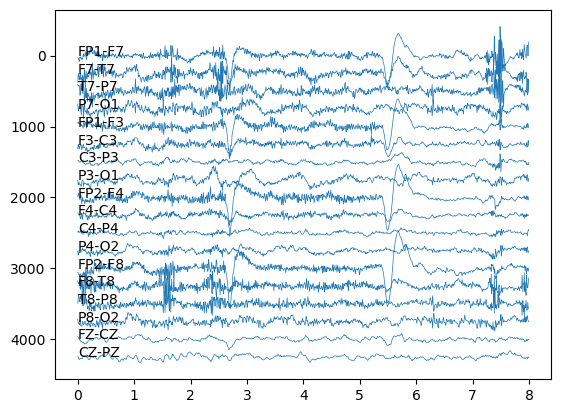

In [14]:
# Show a sample of extracted signals (the last one)

vertical_width = 250
signals = array_signals[-1, :, :]
fs = 128

fig, ax = plt.subplots()
for i in range(signals.shape[0]):
    ax.plot(np.arange(signals.shape[-1])/fs, signals[i, :]+i*vertical_width, linewidth=0.5, color='tab:blue')
    ax.annotate(ch_labels[i], xy=(0, i*vertical_width))
ax.invert_yaxis()
plt.show()

In [15]:
# Checking how much of signals have seizure inside.

array_n = np.where(array_is_sz>.0)[0]
print('Number of all the extracted signals: {}'.format(array_is_sz.size))
print('Number of signals with seizures: {}'.format(array_n.size))
print('Ratio of signals with seizures: {:.3f}'.format(array_n.size/array_is_sz.size))

Number of all the extracted signals: 10068
Number of signals with seizures: 2707
Ratio of signals with seizures: 0.269


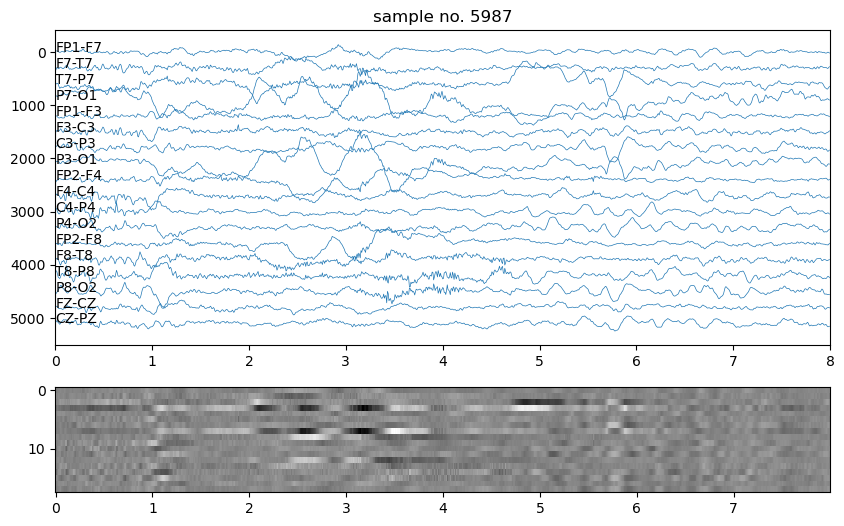

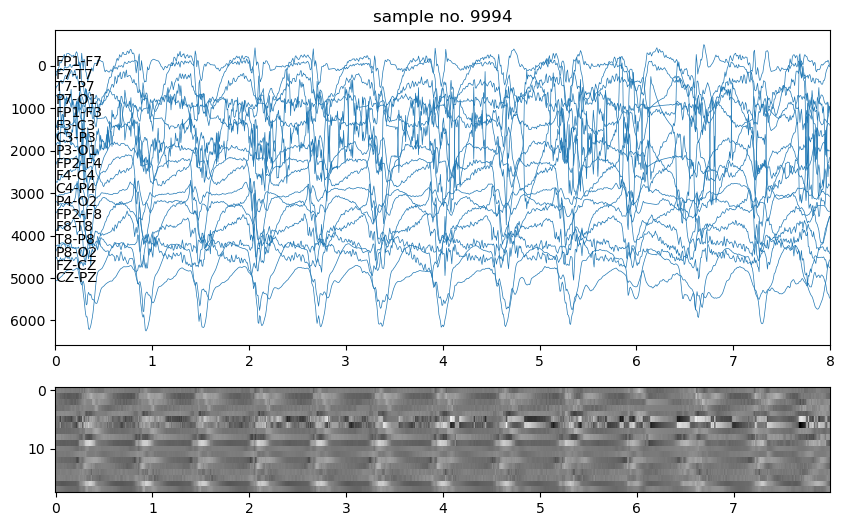

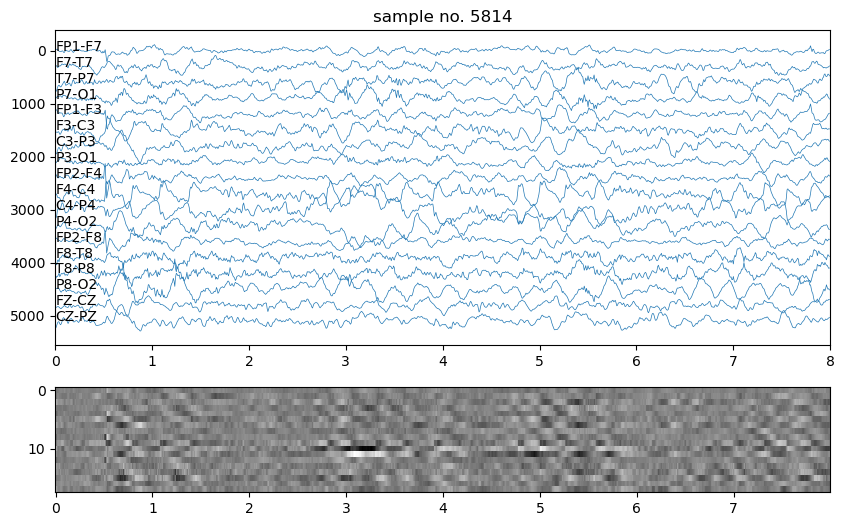

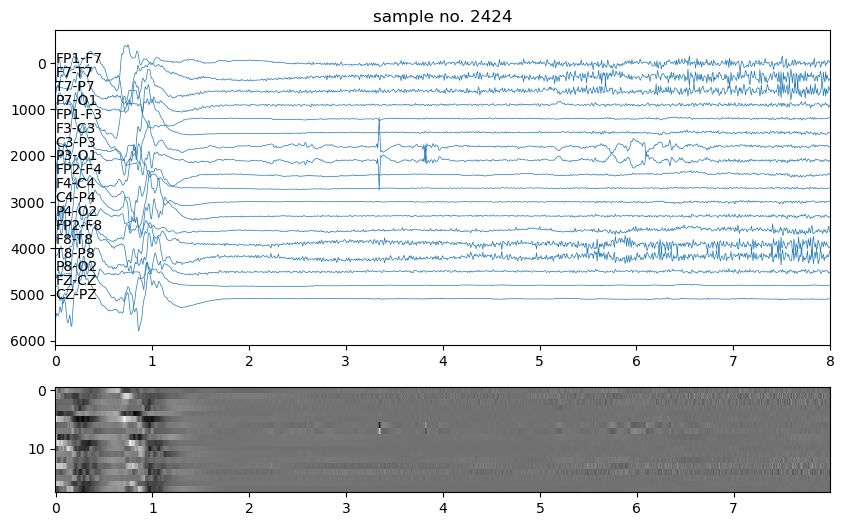

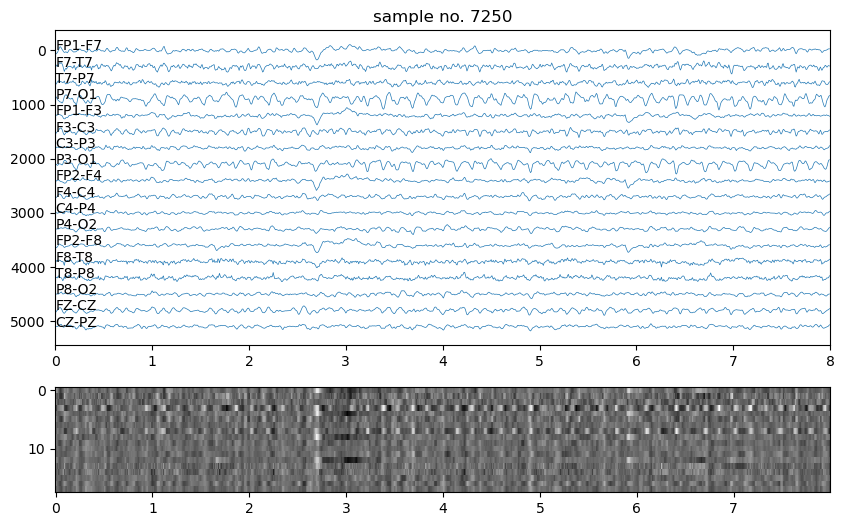

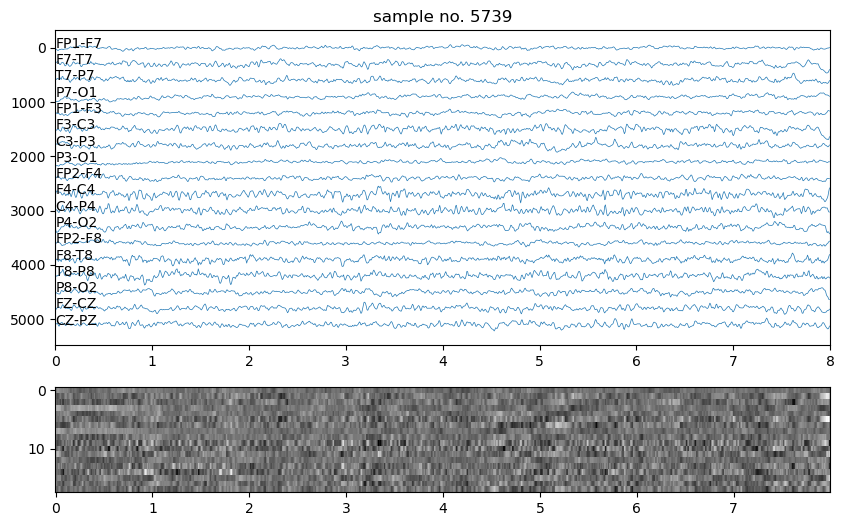

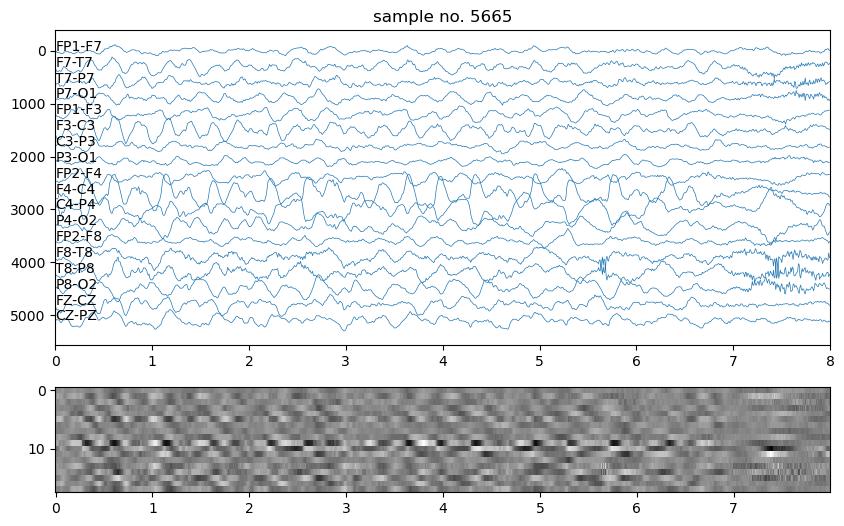

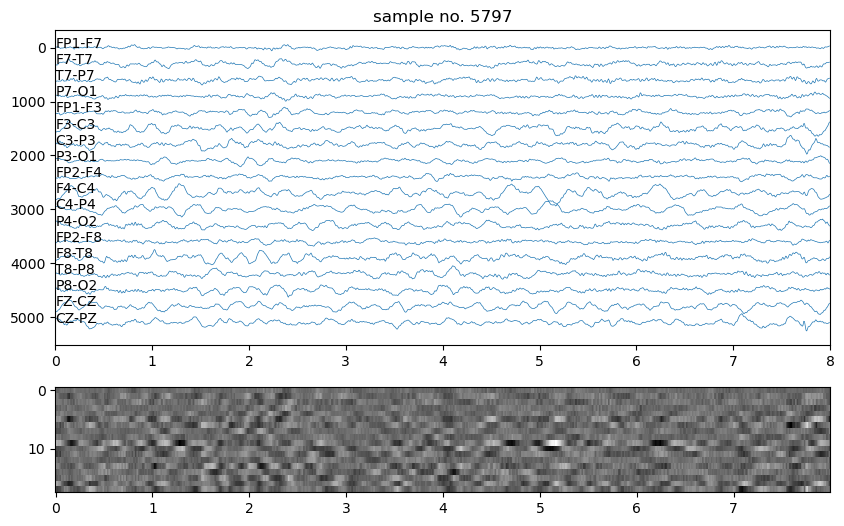

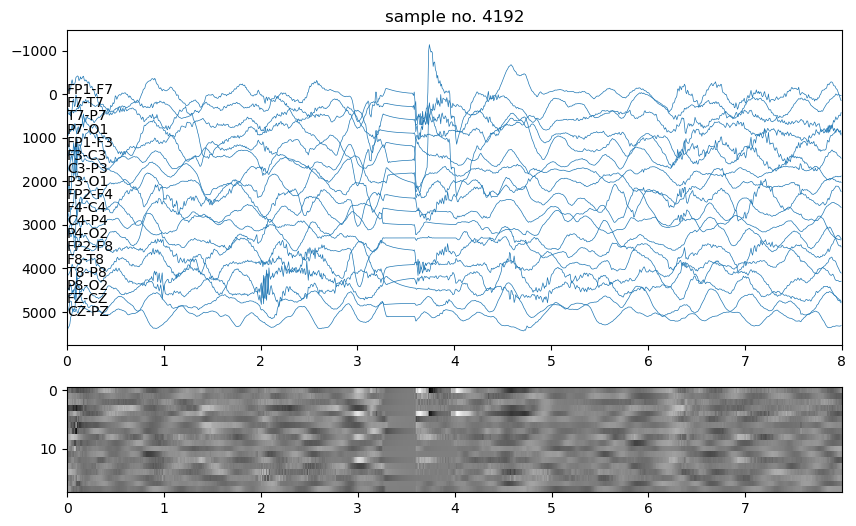

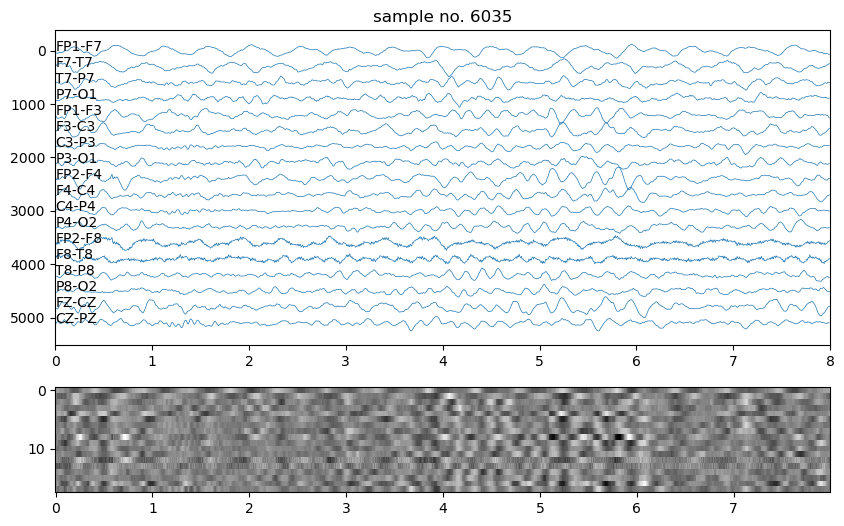

In [16]:
# Let's see samples with seizures.

for n in random.sample(list(array_n), 10):

    vertical_width = 300
    temp_signals = array_signals[n, :, :]
    fs = 128

    fig, ax = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})
    for i in range(temp_signals.shape[0]):
        ax[0].plot(np.arange(temp_signals.shape[-1])/fs, temp_signals[i, :]+i*vertical_width, linewidth=0.5, color='tab:blue')
        ax[0].annotate(ch_labels[i], xy=(0, i*vertical_width))
    ax[0].invert_yaxis()
    ax[0].set_xlim(0, 8)
    ax[0].set_title('sample no. {}'.format(n))
    
    ax[1].pcolormesh(np.arange(temp_signals.shape[-1])/fs, np.arange(len(ch_labels)), temp_signals[:, :], cmap='gray')
    ax[1].invert_yaxis()
    
    plt.show()

In [17]:
from sklearn import model_selection

In [18]:
# CNN will be used. Channel dimension is added.
array_signals = array_signals[:, :, :, np.newaxis]

array_signals.shape

(10068, 18, 1024, 1)

In [19]:
# Splitting training data into training & validation data.

X_train, X_val, y_train, y_val = model_selection.train_test_split(
    array_signals, array_is_sz, test_size=0.3,
    stratify=(array_is_sz>0))

del array_signals, array_is_sz

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [21]:
# Deep learning model

model = keras.models.Sequential()

model.add(layers.Conv2D(filters=64, kernel_size=(2, 4), padding='same', activation='relu', input_shape=X_train.shape[1:]))  #feature extraction
model.add(layers.Conv2D(filters=64, kernel_size=(2, 4), strides=(1, 2),padding='same', activation='relu'))
model.add(layers.MaxPooling2D((1, 2)))  #dimensionality reduction

model.add(layers.Conv2D(filters=128, kernel_size=(2, 4), padding='same', activation='relu'))   #deeper feature extraction
model.add(layers.Conv2D(filters=128, kernel_size=(2, 4), strides=(1, 2), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2, 2))) #further reduction

model.add(layers.Conv2D(filters=256, kernel_size=(4, 4), padding='same', activation='relu')) #high level feature extraction
model.add(layers.Conv2D(filters=256, kernel_size=(4, 4), strides=(1, 2), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((1, 2))) #global reduction

model.add(layers.GlobalAveragePooling2D())  
#model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))  #classification
model.add(layers.Dropout(0.25))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.25))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 18, 1024, 64)   │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 18, 512, 64)    │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 18, 256, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 18, 256, 128)   │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 128, 128)   │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 64, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 9, 64, 256)     │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 9, 32, 256)     │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 16, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,910,657 (7.29 MB)

 Trainable params: 1,910,657 (7.29 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
!pip install pydot graphviz

In [23]:
!pip install pyedflib visualkeras

In [55]:
pip show pydot

Name: pydot
Version: 3.0.4
Summary: Python interface to Graphviz's Dot
Home-page: 
Author: 
Author-email: Ero Carrera <ero.carrera@gmail.com>, Peter Nowee <peter@peternowee.com>, Łukasz <lukaszlapinski7@gmail.com>, "FeRD (Frank Dana)" <ferdnyc@gmail.com>
License: MIT
Location: /opt/anaconda3/lib/python3.11/site-packages
Requires: pyparsing
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [53]:
pip show graphviz

Name: graphviz
Version: 0.20.3
Summary: Simple Python interface for Graphviz
Home-page: https://github.com/xflr6/graphviz
Author: Sebastian Bank
Author-email: sebastian.bank@uni-leipzig.de
License: MIT
Location: /opt/anaconda3/lib/python3.11/site-packages
Requires: 
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [87]:
!pip install pydot-ng

In [63]:
import pyedflib
import pydot
import graphviz
from scipy.signal import find_peaks

In [89]:
from keras.utils import plot_model
#plot_model(model, show_shapes=True, to_file='model.png')
plot_model(model, show_shapes=True, dpi=70)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [73]:
LEARNING_RATE = 1e-4
OPTIMIZER = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE) # adam optimser is a popular choice for training learning models as it adjusts the learning rate for each parameter dynamically and combines Momentum and RMSProp alogs.
model.compile(optimizer=OPTIMIZER, loss='binary_crossentropy', metrics=['accuracy'])

In [75]:
# callbacks
VERBOSE=1
#lr = ReduceLROnPlateau(monitor='val_loss', factor=0.75, patience=5, verbose=VERBOSE, min_le=1e-8)
es = EarlyStopping(monitor='val_loss', patience=20, verbose=VERBOSE, mode='auto', restore_best_weights=True)

callbacks = [es]

In [77]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((7047, 18, 1024, 1), (7047,), (3021, 18, 1024, 1), (3021,))

In [79]:
hist = model.fit(
    x=X_train, y=y_train,
    validation_data=(X_val, y_val),
    epochs=200, # maximum numner of traning iterations over the dataset.
    batch_size=256, #number of samples per batch during traning.
    callbacks=callbacks
)

Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 223s 8s/step - accuracy: 0.5684 - loss: 0.7658 - val_accuracy: 0.7312 - val_loss: 0.6694
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 577s 21s/step - accuracy: 0.6953 - loss: 0.6716 - val_accuracy: 0.7719 - val_loss: 0.6657
Epoch 3/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 236s 8s/step - accuracy: 0.7160 - loss: 0.6588 - val_accuracy: 0.7405 - val_loss: 0.6033
Epoch 4/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 218s 8s/step - accuracy: 0.7287 - loss: 0.6013 - val_accuracy: 0.7686 - val_loss: 0.5551
Epoch 5/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 226s 8s/step - accuracy: 0.7601 - loss: 0.5580 - val_accuracy: 0.7769 - val_loss: 0.5326
Epoch 6/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 222s 8s/step - accuracy: 0.7716 - loss: 0.5210 - val_accuracy: 0.8047 - val_loss: 0.4518
Epoch 7/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 244s 9s/step - accuracy: 0.7945 - loss: 0.4627 - val_accuracy: 0.6687 - val_loss: 0.5925
Epoch 8/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 230s 8s/step - accuracy: 0.7846 - loss: 0.4788 - val_accuracy: 0

In [83]:
model.save('MIT_CHB_Sez_detec_Demo.keras')

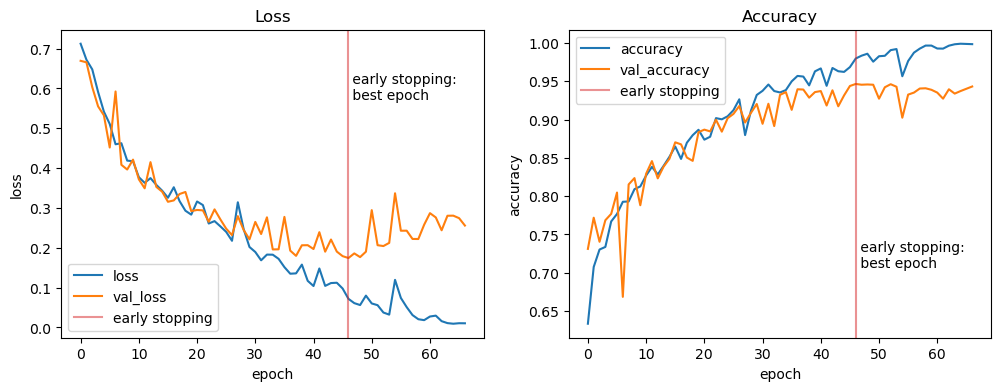

In [91]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(hist.history['loss'], label='loss')
ax[0].plot(hist.history['val_loss'], label='val_loss')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('loss')
ax[0].axvline(x=es.best_epoch, label='early stopping', color='tab:red', alpha=0.5)
r = .2
temp_y = r*min(hist.history['loss'])+(1-r)*max(hist.history['loss'])
ax[0].annotate(' early stopping:\n best epoch', xy=(es.best_epoch, temp_y))
ax[0].set_title('Loss')
ax[0].legend()

ax[1].plot(hist.history['accuracy'], label='accuracy')
ax[1].plot(hist.history['val_accuracy'], label='val_accuracy')
ax[1].set_xlabel('epoch')
ax[1].set_ylabel('accuracy')
r = .8
temp_y = r*min(hist.history['accuracy'])+(1-r)*max(hist.history['accuracy'])
ax[1].axvline(x=es.best_epoch, label='early stopping', color='tab:red', alpha=0.5)
ax[1].annotate(' early stopping:\n best epoch', xy=(es.best_epoch, temp_y))
ax[1].set_title('Accuracy')
ax[1].legend()

plt.show()

In [93]:
def sampling_data_pred(f, verbose=True): #reads eeg file, extract signals and extract data.
    list_signals = []
    list_is_sz = []
    #n_sample = 40
    if verbose==True:
        print('{}: Reading. '.format(f))
    temp_edf =  mne.io.read_raw_edf(f)
    temp_labels = temp_edf.ch_names
    if sum([any([0 if re.match(c, l)==None else 1 for l in temp_edf.ch_names]) for c in ch_labels])==len(ch_labels):
        ch_mapping = {sorted([l for l in temp_edf.ch_names if re.match(c, l)!=None ])[0]:c for c in ch_labels}
        temp_edf.rename_channels(ch_mapping)
        #temp_edf = temp_edf.pick(ch_labels)

        temp_is_sz = np.zeros((temp_edf.n_times,))
        temp_signals = temp_edf.get_data(picks=ch_labels)*1e6  #extract eeg signals.

        if os.path.exists(f+'.seizures'): #if availble process seizure annotation.
            if verbose==True:
                print('sz exists.', end=' ')
            temp_annotation = wfdb.rdann(f, 'seizures')
            for i in range(int(temp_annotation.sample.size/2)):
                temp_is_sz[temp_annotation.sample[i*2]:temp_annotation.sample[i*2+1]]=1
        #else:
            #print('No sz.', end=' ')

        temp_len = temp_edf.n_times  # total number of time points in the recording.

        time_window = 8
        time_step = 4
        fs = int(1/(temp_edf.times[1]-temp_edf.times[0]))
        step_window = time_window*fs
        step = time_step*fs

        # sampling all signals
        temp_array_signals = np.array([temp_signals[:, i*step:i*step+step_window] for i in range((temp_len-step_window)//step)])  #segment the eeg data
        temp_is_sz_ind = np.array([temp_is_sz[i*step:i*step+step_window].sum()/step_window for i in range((temp_len-step_window)//step)])
    else:
        if verbose==True:
            print('EEG {}: Not appropriate channel labels. Reading skipped.'.format(n))

    return temp_array_signals, temp_is_sz_ind

In [95]:
# reading files and prediction and appends the  model predictions and true label lists to seperate list for further evaluation 

list_pred = []
list_true = []

for f in tqdm.tqdm(files_test):
    array_signals, array_is_sz = sampling_data_pred(f, verbose=False)
    array_signals = array_signals[:, :, ::2, np.newaxis]
    
    list_pred.append(model.predict(array_signals, verbose=0))
    list_true.append(array_is_sz)

100%|██████████| 161/161 [18:44<00:00,  6.98s/it]


In [97]:
from sklearn import metrics

In [99]:
# threshold = 0.5
report = metrics.classification_report(np.concatenate(list_true)>0, np.concatenate(list_pred)>.5)
print(report)

              precision    recall  f1-score   support

       False       1.00      0.96      0.98    143236
        True       0.07      0.81      0.12       503

    accuracy                           0.96    143739
   macro avg       0.53      0.88      0.55    143739
weighted avg       1.00      0.96      0.98    143739



In [101]:
# threshold = 0.9
report = metrics.classification_report(np.concatenate(list_true)>0, np.concatenate(list_pred)>.9)
print(report)

              precision    recall  f1-score   support

       False       1.00      0.99      0.99    143236
        True       0.17      0.71      0.27       503

    accuracy                           0.99    143739
   macro avg       0.58      0.85      0.63    143739
weighted avg       1.00      0.99      0.99    143739



In [103]:
roc = metrics.roc_curve(np.concatenate(list_true)>0, np.concatenate(list_pred))
auc = metrics.roc_auc_score(np.concatenate(list_true)>0, np.concatenate(list_pred))

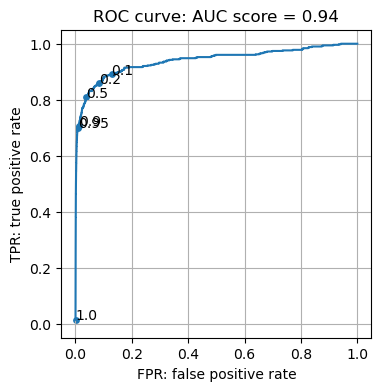

In [105]:
plt.figure(figsize=(4, 4))
plt.plot(roc[0][np.argmin(np.abs(roc[2]-1)):], roc[1][np.argmin(np.abs(roc[2]-1)):])
plt.xlabel('FPR: false positive rate')
plt.ylabel('TPR: true positive rate')
plt.title('ROC curve: AUC score = {:.2f}'.format(auc))

th = [.1, .2, .5, .9, .95, 1.]
ind = [np.argmin(np.abs(roc[2]-l)) for l in th]
plt.scatter(roc[0][ind], roc[1][ind], s=15)
for i, l in enumerate(ind):
    plt.annotate("{}".format(th[i]), xy=(roc[0][l], roc[1][l]))
#plt.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color='black', linewidth=1)
plt.ylim(-.05, 1.05)
plt.xlim(-.05, 1.05)
plt.grid()
#plt.axis('off')
plt.show()

In [107]:
for i, f in enumerate(files_test):  #checks for the corresponding seizure file and print the path along with index.
    if os.path.exists(f+'.seizures'):
        print('Index = {} has seizures: {}'.format(i, f))

Index = 14 has seizures: /Users/prajjwal/Library/CloudStorage/OneDrive-UniversityofAppliedSciencesEuropeGmbH(ehem.BiTSbtk)-Berlin,Hamburg,Iserlohn/Semester 3/Capstone/CHB-MIT Scalp EEG Database/chb02/chb02_16.edf
Index = 23 has seizures: /Users/prajjwal/Library/CloudStorage/OneDrive-UniversityofAppliedSciencesEuropeGmbH(ehem.BiTSbtk)-Berlin,Hamburg,Iserlohn/Semester 3/Capstone/CHB-MIT Scalp EEG Database/chb02/chb02_19.edf
Index = 27 has seizures: /Users/prajjwal/Library/CloudStorage/OneDrive-UniversityofAppliedSciencesEuropeGmbH(ehem.BiTSbtk)-Berlin,Hamburg,Iserlohn/Semester 3/Capstone/CHB-MIT Scalp EEG Database/chb02/chb02_16+.edf
Index = 47 has seizures: /Users/prajjwal/Library/CloudStorage/OneDrive-UniversityofAppliedSciencesEuropeGmbH(ehem.BiTSbtk)-Berlin,Hamburg,Iserlohn/Semester 3/Capstone/CHB-MIT Scalp EEG Database/chb03/chb03_36.edf
Index = 50 has seizures: /Users/prajjwal/Library/CloudStorage/OneDrive-UniversityofAppliedSciencesEuropeGmbH(ehem.BiTSbtk)-Berlin,Hamburg,Iserlohn/

In [109]:
def moving_ave(a, n): #function is intended to calculate the moving average of a 1-dimensional array
    if len(a.shape)!=1:
        print('Not 1 dimension array. return nothing.')
        return
    temp = np.zeros(a.size-n)
    for i in range(n):
        temp = temp+a[i:-n+i]
    temp = temp/n
    
    return temp

In [119]:
# get signals and labels from test data.
n=50
array_signals, array_is_sz = sampling_data_pred(files_test[n])

# preprocess
array_signals=array_signals[:, :, ::2, np.newaxis]

# use deep learning model
pred = model.predict(array_signals)

/Users/prajjwal/Library/CloudStorage/OneDrive-UniversityofAppliedSciencesEuropeGmbH(ehem.BiTSbtk)-Berlin,Hamburg,Iserlohn/Semester 3/Capstone/CHB-MIT Scalp EEG Database/chb03/chb03_35.edf: Reading. 
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 246ms/step


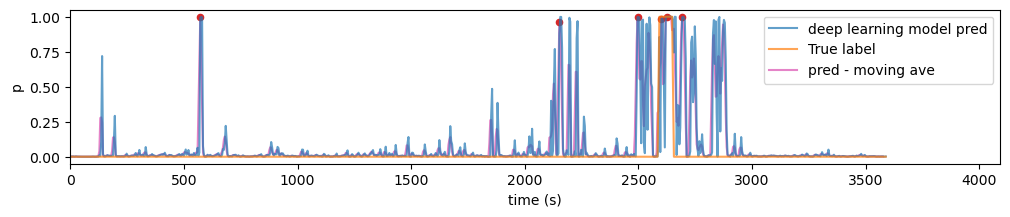

In [121]:
time_window = 8   # visually prediction results from a deep learning model
time_step = 4
mv_win = 3

fig, ax = plt.subplots(figsize=(12, 2))

ax.plot(np.arange(pred.size)*time_step, pred.flatten(), alpha=0.7, label='deep learning model pred')
ax.plot(np.arange(pred.size)*time_step, array_is_sz, alpha=.7, label='True label')

pred_moving_ave = moving_ave(pred.flatten(), mv_win)
pred_peaks, _ = find_peaks(pred_moving_ave, height=.95, distance=6)
ax.plot(np.arange(pred.size-mv_win)*time_step, pred_moving_ave,
        alpha=.9, label='pred - moving ave', color='tab:pink', zorder=0)
ax.scatter(pred_peaks*time_step, pred_moving_ave[pred_peaks], s=20, color='tab:red')

ax.set_xlabel('time (s)')
ax.set_ylabel('p')
ax.set_xlim(0, pred.size*time_step+500)
ax.legend(loc='upper right')
plt.show()

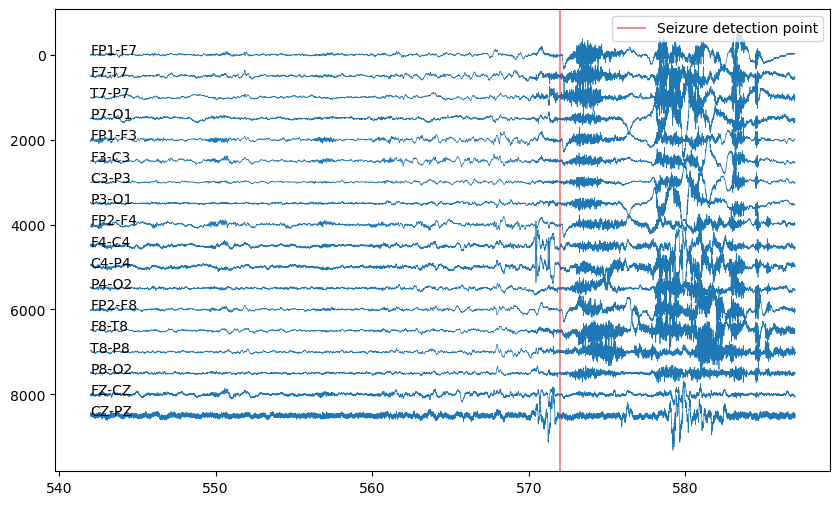

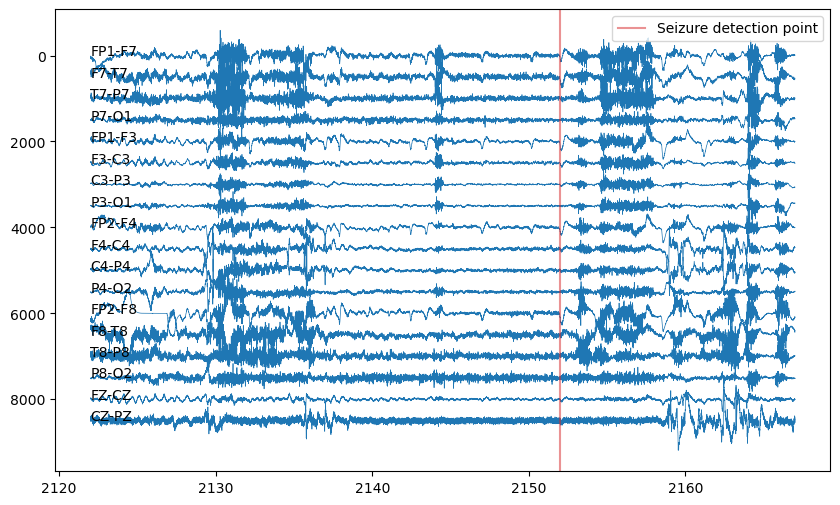

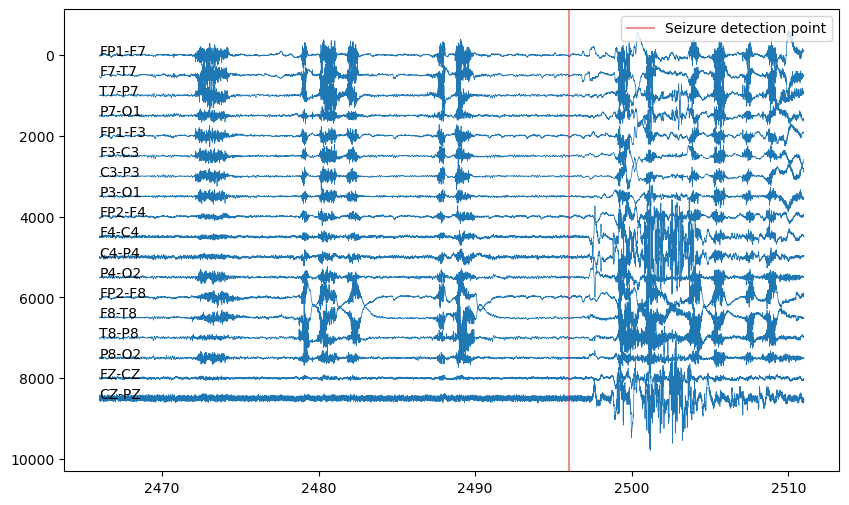

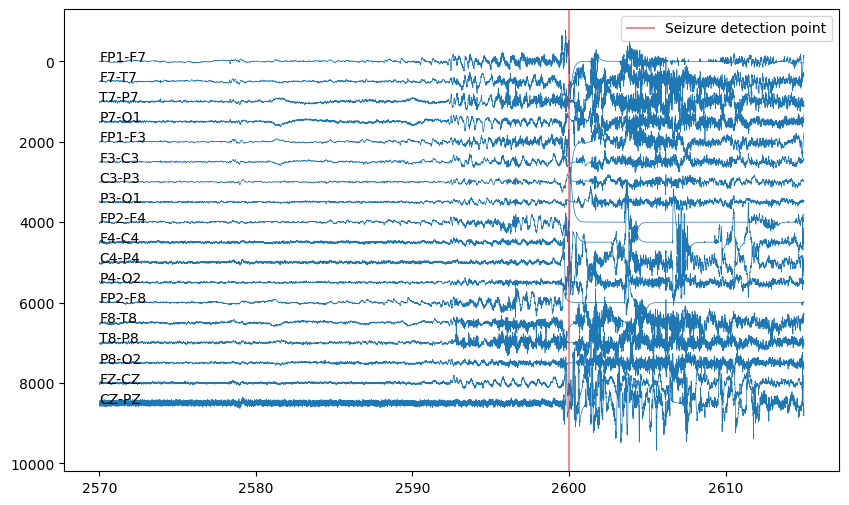

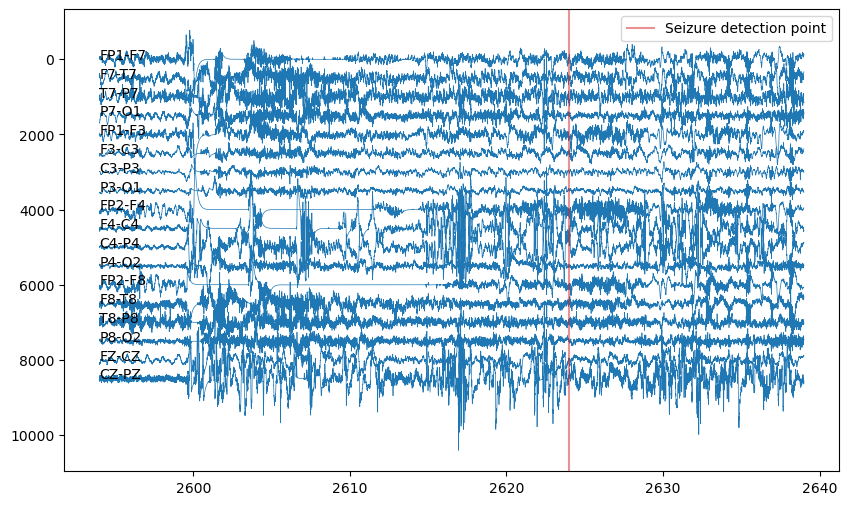

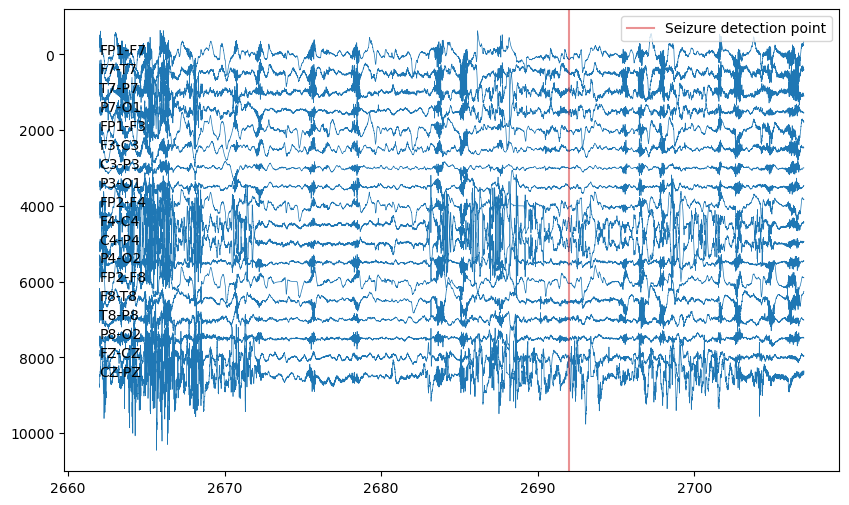

In [123]:
if pred_peaks.size==0: #visualizing the EEG signals around the predicted seizure events by plotting the EEG signals within a window around the detected peaks
    print('No seizure detected.')
else:
    f = files_test[n]
    temp_edf =  mne.io.read_raw_edf(f)
    temp_labels = temp_edf.ch_names
    if sum([any([0 if re.match(c, l)==None else 1 for l in temp_edf.ch_names]) for c in ch_labels])==len(ch_labels):
        ch_mapping = {sorted([l for l in temp_edf.ch_names if re.match(c, l)!=None ])[0]:c for c in ch_labels}
        temp_edf.rename_channels(ch_mapping)
        #temp_edf = temp_edf.pick(ch_labels)

        temp_is_sz = np.zeros((temp_edf.n_times,))
        temp_signals = temp_edf.get_data(picks=ch_labels)*1e6

    fs = int(1/(temp_edf.times[1]-temp_edf.times[0]))
    for n_peak in range(pred_peaks.size):
        ind_peak = pred_peaks[n_peak]*time_step*fs
        backward_steps = 30*fs
        forward_steps = 15*fs
        vertical_width=500

        fig, ax = plt.subplots(figsize=(10, 6))
        for i in range(temp_signals.shape[0]):
            ax.plot(np.arange(ind_peak-backward_steps, ind_peak+forward_steps)/fs,
                    temp_signals[i, ind_peak-backward_steps:ind_peak+forward_steps]+i*vertical_width, linewidth=0.5, color='tab:blue')
            ax.annotate(ch_labels[i], xy=((ind_peak-backward_steps)/fs, i*vertical_width))
        ax.axvline(x=ind_peak/fs, color='tab:red', alpha=0.5, label='Seizure detection point')
        ax.invert_yaxis()
        ax.legend(loc='upper right')
        plt.show()
    #ax.set_xlim(0, 8)

    temp_edf.close()